# Đọc và Trực quan hóa file NetCDF (.nc)

File notebook này sẽ hướng dẫn bạn cách sử dụng thư viện `xarray` và `matplotlib` để mở, kiểm tra, và vẽ biểu đồ dữ liệu từ file `.nc` mà chúng ta đã tải về.


In [1]:
# Bước 1: Cài đặt các thư viện cần thiết
# Chạy cell này nếu bạn chưa cài đặt các thư viện này
%pip install xarray netcdf4 matplotlib cartopy


  Using cached xarray-2024.7.0-py3-none-any.whl.metadata (11 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   -------------------------- ------------- 0.8/1.2 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 4.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------- -------------------------------- 1.3/7.0 MB 6.7 MB/s eta 0:00:01
   -------------- ------------------------- 2.6/7.0 MB 6.6 MB/s eta 0:00:01
   ----------------------- ---------------- 4.2/7.0 MB 6.6 MB/s eta 0:00:01
   -------------------------------- ------- 5.8/7.0 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 6.9 MB/s eta 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Bước 2: Import các thư viện
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np


In [30]:
# Bước 3: Mở file NetCDF

# Thay đổi đường dẫn này trỏ đến đúng file .nc của bạn
file_path = 'data/latest_grid.nc'

# Mở file bằng xarray
try:
    ds = xr.open_dataset(file_path)
    # In ra cấu trúc của bộ dữ liệu
    # Đây là bước quan trọng nhất để hiểu file của bạn chứa những gì
    print(ds)
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file tại '{file_path}'.")
    print("Vui lòng đảm bảo bạn đã chạy script `fetch_grid_cron.py` để tạo file cache.")


<xarray.Dataset> Size: 367MB
Dimensions:    (depth: 83, latitude: 341, longitude: 321, time: 2)
Coordinates:
  * depth      (depth) float32 332B 0.494 0.494 1.541 ... 5.728e+03 5.728e+03
  * latitude   (latitude) float32 1kB 7.0 7.083 7.083 7.167 ... 23.92 23.92 24.0
  * longitude  (longitude) float32 1kB 102.0 102.1 102.1 ... 117.9 117.9 118.0
  * time       (time) datetime64[ns] 16B 2025-10-03T12:00:00 2025-10-04
Data variables:
    thetao     (time, depth, latitude, longitude) float32 73MB ...
    so         (time, depth, latitude, longitude) float32 73MB ...
    po4        (time, depth, latitude, longitude) float32 73MB ...
    o2         (time, depth, latitude, longitude) float32 73MB ...
    chl        (time, depth, latitude, longitude) float32 73MB ...
    VHM0       (time, latitude, longitude) float64 2MB ...
    VTPK       (time, latitude, longitude) float64 2MB ...
Attributes:
    references:                http://marine.copernicus.eu
    title:                     daily mean

## Khám phá Dữ liệu

Kết quả ở trên cho bạn thấy:
- **Dimensions**: Các chiều của dữ liệu (ví dụ: `longitude`, `latitude`, `depth`, `time`).
- **Coordinates**: Các giá trị tọa độ cho mỗi chiều.
- **Data variables**: Các biến dữ liệu chính mà chúng ta cần (ví dụ: `thetao`, `so`, `o2`...).


In [19]:
# Bước 4: Truy cập một biến dữ liệu cụ thể

# Ví dụ: Lấy biến nhiệt độ ('thetao')
if 'ds' in locals() and 'thetao' in ds:
    temperature_data = ds['thetao']
    print(temperature_data)
else:
    print("Không thể truy cập biến 'thetao'. Vui lòng kiểm tra lại file dữ liệu.")


<xarray.DataArray 'thetao' (time: 2, depth: 83, latitude: 341, longitude: 321)> Size: 73MB
[18170526 values with dtype=float32]
Coordinates:
  * depth      (depth) float32 332B 0.494 0.494 1.541 ... 5.728e+03 5.728e+03
  * latitude   (latitude) float32 1kB 7.0 7.083 7.083 7.167 ... 23.92 23.92 24.0
  * longitude  (longitude) float32 1kB 102.0 102.1 102.1 ... 117.9 117.9 118.0
  * time       (time) datetime64[ns] 16B 2025-10-03T12:00:00 2025-10-04
Attributes:
    unit_long:      Degrees Celsius
    valid_max:      40.0
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    valid_min:      -10.0
    units:          degrees_C


In [11]:
# Bước 5: Lấy giá trị tại một điểm và độ sâu cụ thể

if 'ds' in locals():
    # Tọa độ và độ sâu bạn muốn tra cứu
    target_lat = 16.1  # Vĩ độ (ví dụ: gần Đà Nẵng)
    target_lon = 108.4 # Kinh độ
    target_depth = 50   # Độ sâu (mét)

    # Dùng .sel() để chọn dữ liệu ở tọa độ và độ sâu gần nhất
    point_data = ds.sel(latitude=target_lat, longitude=target_lon, depth=target_depth, method='nearest')

    # Lấy giá trị nhiệt độ tại điểm đó (xử lý khi còn chiều 'time')
    if 'thetao' in point_data:
        temp_da = point_data['thetao']
        # Chọn thời điểm đầu tiên nếu tồn tại chiều time
        if 'time' in temp_da.dims:
            temp_da = temp_da.isel(time=0)
        # Ghi nhận toạ độ, độ sâu gần nhất mà dataset đã chọn
        chosen_lat = float(point_data['latitude'].values) if 'latitude' in point_data.coords else float(temp_da['latitude'].values)
        chosen_lon = float(point_data['longitude'].values) if 'longitude' in point_data.coords else float(temp_da['longitude'].values)
        if 'depth' in point_data.coords:
            chosen_depth = float(point_data['depth'].values)
        elif 'depth' in temp_da.coords:
            chosen_depth = float(temp_da['depth'].values)
        else:
            chosen_depth = float(target_depth)
        # Lấy giá trị ban đầu tại điểm gần nhất
        value_arr = temp_da.squeeze().values
        if np.isscalar(value_arr):
            value = float(value_arr)
        else:
            value = float(np.ravel(value_arr)[0])
        # Nếu NaN, tìm giá trị hợp lệ gần nhất bằng cách mở rộng cửa sổ tìm kiếm
        nearest_found = False
        nearest_lat = None
        nearest_lon = None
        if np.isnan(value):
            for r in [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]:
                sub = ds['thetao']
                if 'time' in sub.dims:
                    sub = sub.isel(time=0)
                sub = sub.sel(depth=target_depth, method='nearest').sel(
                    latitude=slice(target_lat - r, target_lat + r),
                    longitude=slice(target_lon - r, target_lon + r)
                )
                if sub.size == 0:
                    continue
                # Tạo lưới lat/lon và tìm điểm hợp lệ gần nhất
                lat_vals = sub['latitude'].values
                lon_vals = sub['longitude'].values
                if lat_vals.size == 0 or lon_vals.size == 0:
                    continue
                lat_grid, lon_grid = np.meshgrid(lat_vals, lon_vals, indexing='ij')
                val_grid = sub.values
                mask = ~np.isnan(val_grid)
                if mask.any():
                    dist = np.abs(lat_grid - target_lat) + np.abs(lon_grid - target_lon)
                    dist_masked = np.where(mask, dist, np.inf)
                    i, j = np.unravel_index(np.argmin(dist_masked), dist_masked.shape)
                    nearest_value = float(val_grid[i, j])
                    nearest_lat = float(lat_grid[i, j])
                    nearest_lon = float(lon_grid[i, j])
                    value = nearest_value
                    nearest_found = True
                    break
        # In thông tin lựa chọn và kết quả
        print(
            f"Điểm gần nhất được dataset chọn: lat={chosen_lat:.4f}, lon={chosen_lon:.4f}, depth~{chosen_depth:.1f}m"
        )
        if nearest_found:
            print(
                f"Giá trị gần nhất không phải NaN tìm được tại: lat={nearest_lat:.4f}, lon={nearest_lon:.4f}"
            )
        # In kết quả dạng số và dạng chuỗi (kể cả khi NaN)
        value_str = "NaN" if np.isnan(value) else f"{value:.2f}"
        print(
            f"Nhiệt độ ở ({target_lat}, {target_lon}) tại độ sâu ~{target_depth}m: {value_str} °C"
        )
        if np.isnan(value) and not nearest_found:
            print(
                "Không tìm thấy điểm lân cận hợp lệ trong bán kính tới 1.0°.\n"
                "Hãy thử giảm độ sâu, thay đổi toạ độ, hoặc xác nhận biến/chiều trong dataset."
            )
    else:
        print("Không tìm thấy biến nhiệt độ 'thetao' tại điểm đã chọn.")


Điểm gần nhất được dataset chọn: lat=16.0833, lon=108.4167, depth~47.4m
Nhiệt độ ở (16.1, 108.4) tại độ sâu ~50m: NaN °C
Không tìm thấy điểm lân cận hợp lệ trong bán kính tới 1.0°.
Hãy thử giảm độ sâu, thay đổi toạ độ, hoặc xác nhận biến/chiều trong dataset.


## Trực quan hóa Dữ liệu

Chúng ta sẽ vẽ một bản đồ nhiệt 2D đơn giản cho nhiệt độ bề mặt.


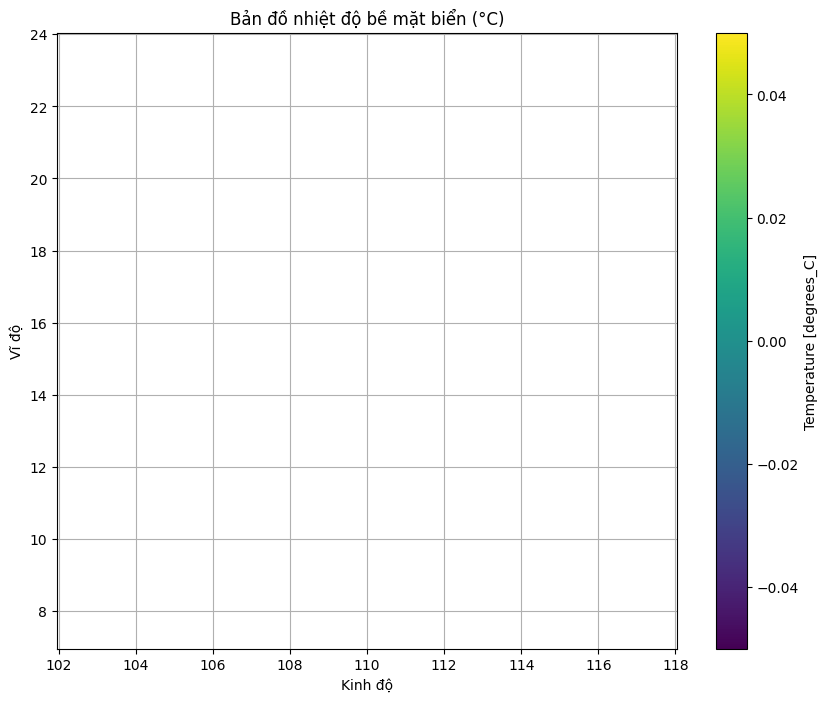

In [10]:
# Bước 6: Vẽ bản đồ nhiệt độ bề mặt

if 'ds' in locals() and 'thetao' in ds:
    # Lấy dữ liệu nhiệt độ ở tầng mặt biển (chỉ số depth = 0)
    surface_temp = ds['thetao'].isel(depth=0, time=0)

    # Thiết lập kích thước cho biểu đồ
    plt.figure(figsize=(10, 8))

    # Dùng pcolormesh để vẽ bản đồ nhiệt
    # Thêm cmap='viridis' để có màu sắc đẹp hơn
    surface_temp.plot(cmap='viridis')

    # Thêm tiêu đề và nhãn
    plt.title('Bản đồ nhiệt độ bề mặt biển (°C)')
    plt.xlabel('Kinh độ')
    plt.ylabel('Vĩ độ')
    plt.grid(True)

    # Hiển thị biểu đồ
    plt.show()
else:
    print("Không thể vẽ biểu đồ vì không có dữ liệu nhiệt độ.")


In [ ]:
# Đừng quên đóng file sau khi làm việc xong
if 'ds' in locals():
    ds.close()
    print("Dataset đã được đóng.")


In [18]:
from IPython.display import display
# Bước 5b: Log dữ liệu dạng DataFrame quanh điểm quan tâm (ổn định, không lỗi sort)

if 'ds' in locals():
    # Dùng lại target_lat, target_lon, target_depth nếu đã đặt ở cell trước
    try:
        target_lat
        target_lon
        target_depth
    except NameError:
        target_lat = 16.1
        target_lon = 108.4
        target_depth = 50

    # Lấy biến thetao tại time=0 (nếu có), depth gần nhất, và cửa sổ không gian nhỏ
    da = ds['thetao'] if 'thetao' in ds else None
    if da is None:
        print("Không tìm thấy biến 'thetao'.")
    else:
        if 'time' in da.dims:
            da = da.isel(time=0)
        da = da.sel(depth=target_depth, method='nearest')

        # Cửa sổ xem dữ liệu (có thể chỉnh):
        r = 0.3
        da_sub = da.sel(
            latitude=slice(target_lat - r, target_lat + r),
            longitude=slice(target_lon - r, target_lon + r)
        )

        # Chuyển về DataFrame
        df = da_sub.to_dataframe(name='thetao').reset_index()

        # Tự động nhận diện cột toạ độ có sẵn trong DataFrame
        cand_lat = ["latitude", "lat", "nav_lat", "y"]
        cand_lon = ["longitude", "lon", "nav_lon", "x"]
        lat_col = next((c for c in cand_lat if c in df.columns), None)
        lon_col = next((c for c in cand_lon if c in df.columns), None)

        # Tạo cột khoảng cách Manhattan nếu có đủ toạ độ, nếu không đặt vô cùng để về cuối
        if lat_col and lon_col:
            df['manhattan_dist'] = (df[lat_col] - target_lat).abs() + (df[lon_col] - target_lon).abs()
        else:
            df['manhattan_dist'] = np.inf

        # Ưu tiên các giá trị không NaN trước, sau đó sắp theo độ lớn |thetao| giảm dần
        df['is_nan'] = df['thetao'].isna()
        df['abs_thetao'] = df['thetao'].abs()
        df_sorted = df.sort_values(by=['is_nan', 'abs_thetao'], ascending=[True, False], kind='mergesort').drop(columns=['is_nan', 'abs_thetao'])

        # Log thông tin tổng quan và 20 dòng đầu
        total = len(df_sorted)
        n_nan = int(df_sorted['thetao'].isna().sum())
        print(f"Tổng bản ghi trong cửa sổ ~±{r}°: {total} | NaN: {n_nan}")
        if lat_col and lon_col:
            print(f"Cột toạ độ: lat='{lat_col}', lon='{lon_col}'")
        else:
            print("Không nhận diện được cột toạ độ trong DataFrame; 'manhattan_dist' sẽ là inf.")
        print("Top 5 theo |thetao| (NaN ở cuối):")
        display(df_sorted.head(5))
        print("Xem 20 dòng đầu tiên:")
        display(df_sorted.head(20))
else:
    print("Dataset 'ds' chưa được khởi tạo.")


Tổng bản ghi trong cửa sổ ~±0.3°: 144 | NaN: 144
Cột toạ độ: lat='latitude', lon='longitude'
Top 5 theo |thetao| (NaN ở cuối):


,latitude,longitude,depth,time,thetao,manhattan_dist
0,15.833333,108.166664,47.373692,2025-10-03 12:00:00,NaN,0.500005
1,15.833333,108.166687,47.373692,2025-10-03 12:00:00,NaN,0.499982
2,15.833333,108.250000,47.373692,2025-10-03 12:00:00,NaN,0.416669
3,15.833333,108.333336,47.373692,2025-10-03 12:00:00,NaN,0.333333
4,15.833333,108.333344,47.373692,2025-10-03 12:00:00,NaN,0.333325


Xem 20 dòng đầu tiên:


,latitude,longitude,depth,time,thetao,manhattan_dist
0,15.833333,108.166664,47.373692,2025-10-03 12:00:00,NaN,0.500005
1,15.833333,108.166687,47.373692,2025-10-03 12:00:00,NaN,0.499982
2,15.833333,108.250000,47.373692,2025-10-03 12:00:00,NaN,0.416669
3,15.833333,108.333336,47.373692,2025-10-03 12:00:00,NaN,0.333333
4,15.833333,108.333344,47.373692,2025-10-03 12:00:00,NaN,0.333325
5,15.833333,108.416664,47.373692,2025-10-03 12:00:00,NaN,0.283330
6,15.833333,108.416687,47.373692,2025-10-03 12:00:00,NaN,0.283353
7,15.833333,108.500000,47.373692,2025-10-03 12:00:00,NaN,0.366666
8,15.833333,108.583336,47.373692,2025-10-03 12:00:00,NaN,0.450002
9,15.833333,108.583344,47.373692,2025-10-03 12:00:00,NaN,0.450009


In [20]:
# Bước 5c: Chẩn đoán vì sao ra NaN (kiểm tra độ sâu hợp lệ tại điểm gần nhất)

if 'ds' in locals() and 'thetao' in ds:
    da = ds['thetao']
    if 'time' in da.dims:
        da = da.isel(time=0)

    # Dùng lại target_lat/target_lon/target_depth nếu có
    try:
        target_lat
        target_lon
        target_depth
    except NameError:
        target_lat = 16.1
        target_lon = 108.4
        target_depth = 50

    # Chọn theo toạ độ gần nhất (mọi độ sâu)
    prof = da.sel(latitude=target_lat, longitude=target_lon, method='nearest')  # dims: depth x (lat x lon collapsed)

    # Toạ độ thực sự được chọn
    chosen_lat = float(prof['latitude'].values if 'latitude' in prof.coords else da.sel(latitude=target_lat, method='nearest')['latitude'].values)
    chosen_lon = float(prof['longitude'].values if 'longitude' in prof.coords else da.sel(longitude=target_lon, method='nearest')['longitude'].values)

    # Giá trị theo toàn bộ cột nước tại điểm gần nhất
    valid_mask = prof.notnull()
    valid_depths = prof['depth'].values[valid_mask.values]
    num_valid = int(valid_mask.sum().item())

    print(f"Điểm gần nhất: lat={chosen_lat:.4f}, lon={chosen_lon:.4f}")
    print(f"Số mức độ sâu có dữ liệu (time=0): {num_valid}/{prof.sizes.get('depth', 0)}")

    # Kiểm tra giá trị ở độ sâu mong muốn (nearest theo depth)
    val_at_depth = da.sel(latitude=chosen_lat, longitude=chosen_lon, depth=target_depth, method='nearest').item() if da.sel(latitude=chosen_lat, longitude=chosen_lon, depth=target_depth, method='nearest').size == 1 else np.nan
    print(f"Giá trị tại độ sâu gần {target_depth} m: {('NaN' if np.isnan(val_at_depth) else f'{val_at_depth:.2f} °C')}")

    # Gợi ý nhanh nếu tất cả NaN
    if num_valid == 0:
        print("Cột nước tại điểm này toàn NaN (có thể là trên đất liền hoặc ngoài phạm vi biến này). Thử dịch toạ độ hoặc đổi biến.")
    else:
        # Liệt kê 10 mức độ sâu hợp lệ đầu tiên
        head_n = min(10, len(valid_depths))
        if head_n > 0:
            print("Một số mức độ sâu có dữ liệu (m):", np.round(valid_depths[:head_n], 2))
        # Nếu giá trị tại độ sâu yêu cầu là NaN, có thể đáy nông hơn độ sâu yêu cầu
        if np.isnan(val_at_depth):
            max_valid_depth = float(valid_depths.max()) if len(valid_depths) > 0 else np.nan
            print(f"Độ sâu tối đa có dữ liệu tại điểm này ~ {('NaN' if np.isnan(max_valid_depth) else f'{max_valid_depth:.1f} m')}.")
            print("Nếu max_depth < target_depth, đây là nguyên nhân: nước nông hơn độ sâu yêu cầu.")
else:
    print("Dataset/biến 'thetao' chưa sẵn sàng.")


Điểm gần nhất: lat=16.0833, lon=108.4167
Số mức độ sâu có dữ liệu (time=0): 0/83
Giá trị tại độ sâu gần 50 m: NaN
Cột nước tại điểm này toàn NaN (có thể là trên đất liền hoặc ngoài phạm vi biến này). Thử dịch toạ độ hoặc đổi biến.


In [24]:
# Bước 5d: Liệt kê tất cả các trường hợp có thetao là số (non-NaN)

from IPython.display import display

if 'ds' in locals() and 'thetao' in ds:
    # Tham số
    try:
        target_lat
        target_lon
        target_depth
    except NameError:
        target_lat = 16.1
        target_lon = 108.4
        target_depth = 50

    # r=None để lấy toàn bộ; đặt r=0.3 (hoặc số khác) để chỉ lấy vùng lân cận
    r = None  # None hoặc một số float (độ)
    export_csv = False  # True nếu muốn lưu CSV
    csv_path = 'thetao_non_nan.csv'

    # Chuẩn bị dữ liệu
    da = ds['thetao']
    if 'time' in da.dims:
        da = da.isel(time=0)
    da = da.sel(depth=target_depth, method='nearest')

    if isinstance(r, (int, float)):
        da_sub = da.sel(
            latitude=slice(target_lat - r, target_lat + r),
            longitude=slice(target_lon - r, target_lon + r)
        )
    else:
        da_sub = da

    df = da_sub.to_dataframe(name='thetao').reset_index()
    non_nan = df[df['thetao'].notna()].copy()

    # Thêm khoảng cách (nếu có cột lat/lon) để tiện sắp xếp/xem gần điểm mục tiêu
    cand_lat = ["latitude", "lat", "nav_lat", "y"]
    cand_lon = ["longitude", "lon", "nav_lon", "x"]
    lat_col = next((c for c in cand_lat if c in non_nan.columns), None)
    lon_col = next((c for c in cand_lon if c in non_nan.columns), None)
    if lat_col and lon_col:
        non_nan['manhattan_dist'] = (non_nan[lat_col] - target_lat).abs() + (non_nan[lon_col] - target_lon).abs()
        non_nan = non_nan.sort_values(by=['manhattan_dist'], ascending=True, kind='mergesort')

    total_all = len(df)
    total_non_nan = len(non_nan)
    print(f"Tổng bản ghi (phạm vi {'toàn miền' if r is None else f'±{r}°'}) = {total_all} | Non-NaN = {total_non_nan}")

    # Hiển thị trước tối đa 100 dòng để tránh tràn output
    preview_n = 100
    if total_non_nan == 0:
        print("Không có bản ghi non-NaN trong phạm vi đã chọn.")
    else:
        print(f"Hiển thị {min(preview_n, total_non_nan)} dòng đầu:")
        display(non_nan.head(preview_n))

    if export_csv and total_non_nan > 0:
        non_nan.to_csv(csv_path, index=False)
        print(f"Đã lưu CSV: {csv_path}")
else:
    print("Dataset/biến 'thetao' chưa sẵn sàng.")


Tổng bản ghi (phạm vi toàn miền) = 109461 | Non-NaN = 0
Không có bản ghi non-NaN trong phạm vi đã chọn.


In [23]:
# Bước 5e: Log giá trị gốc (raw) của thetao

import numpy as np

if 'ds' in locals() and 'thetao' in ds:
    da = ds['thetao']
    # Không thay đổi dữ liệu: chỉ lấy raw values (giữ nguyên các chiều)
    raw = da.values  # ndarray: (time, depth, latitude, longitude)

    print("thetao raw info:")
    print("- dtype:", raw.dtype)
    print("- shape:", raw.shape)

    # Thống kê nhanh bỏ NaN
    finite = np.isfinite(raw)
    count_all = raw.size
    count_finite = int(finite.sum())
    print(f"- total elements: {count_all} | finite: {count_finite} | nan: {count_all - count_finite}")

    if count_finite > 0:
        min_val = float(np.nanmin(raw))
        max_val = float(np.nanmax(raw))
        mean_val = float(np.nanmean(raw))
        print(f"- min: {min_val:.4f} | max: {max_val:.4f} | mean: {mean_val:.4f}")

        # Lấy 10 giá trị hữu hạn đầu tiên để log
        sample_vals = raw[np.isfinite(raw)].ravel()[:10]
        print("- first finite values:", np.array2string(sample_vals, precision=4, separator=', '))
    else:
        print("- Không có giá trị hữu hạn (tất cả đều NaN).")

    # Tuỳ chọn: in một cửa sổ nhỏ quanh điểm mục tiêu để dễ nhìn
    try:
        target_lat
        target_lon
    except NameError:
        target_lat = 16.1
        target_lon = 108.4

    if all(coord in da.coords for coord in ['latitude', 'longitude']):
        # Lấy time=0, depth gần bề mặt để xem nhanh
        rlat = 1  # số ô lưới mỗi phía
        rlon = 1
        t_sel = 0 if 'time' in da.dims else None
        d_sel = 0 if 'depth' in da.dims else None
        sub = da
        if t_sel is not None:
            sub = sub.isel(time=t_sel)
        if d_sel is not None:
            sub = sub.isel(depth=d_sel)
        sub = sub.sel(latitude=target_lat, longitude=target_lon, method='nearest')
        lat0 = float(sub['latitude'].values)
        lon0 = float(sub['longitude'].values)
        lat_idx = int(np.argmin(np.abs(da['latitude'].values - lat0)))
        lon_idx = int(np.argmin(np.abs(da['longitude'].values - lon0)))
        lat_slice = slice(max(0, lat_idx-rlat), min(da.sizes['latitude'], lat_idx+rlat+1))
        lon_slice = slice(max(0, lon_idx-rlon), min(da.sizes['longitude'], lon_idx+rlon+1))
        small = da.isel(time=t_sel if t_sel is not None else 0,
                        depth=d_sel if d_sel is not None else 0,
                        latitude=lat_slice,
                        longitude=lon_slice).values
        print(f"- small window at time={t_sel}, depth={d_sel}, around (lat={lat0}, lon={lon0}):")
        print(small)
else:
    print("Dataset/biến 'thetao' chưa sẵn sàng.")


thetao raw info:
- dtype: float32
- shape: (2, 83, 341, 321)
- total elements: 18170526 | finite: 770769 | nan: 17399757
- min: 1.7526 | max: 31.1844 | mean: 21.3185
- first finite values: [29.9559, 29.89  , 29.8794, 29.8715, 29.87  , 29.8416, 29.8645, 29.8839,
 29.8777, 29.9206]
- small window at time=0, depth=0, around (lat=16.083335876464844, lon=108.41666412353516):
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]


In [26]:
# Bước 5f: Thử tự động chọn một điểm ngoài khơi (vùng biển) có thetao hợp lệ

import numpy as np

if 'ds' in locals() and 'thetao' in ds:
    da = ds['thetao']
    if 'time' in da.dims:
        da = da.isel(time=0)

    # Danh sách toạ độ ngoài khơi (xa bờ hơn, biển Đông VN)
    candidates = [
        (16.0, 114.0),
        (14.0, 113.0),
        (12.0, 112.0),
        (10.0, 111.0),
        (18.0, 114.5),
        (15.0, 113.5),
        (16.5, 115.0)
    ]
    depths = [0, 5, 10, 20, 50, 100]

    found = False
    chosen = None
    val = np.nan

    for lat_c, lon_c in candidates:
        for d in depths:
            try:
                pt = da.sel(latitude=lat_c, longitude=lon_c, method='nearest').sel(depth=d, method='nearest')
                v = float(pt.values)
            except Exception:
                v = np.nan
            if np.isfinite(v):
                found = True
                chosen = (float(pt['latitude'].values), float(pt['longitude'].values), float(pt['depth'].values))
                val = v
                break
        if found:
            break

    if found:
        target_lat, target_lon, target_depth = chosen
        print(f"Đã tìm thấy điểm biển hợp lệ: lat={target_lat:.4f}, lon={target_lon:.4f}, depth~{target_depth:.1f} m")
        print(f"thetao ≈ {val:.2f} °C")
        # In một cửa sổ nhỏ 3x3 quanh điểm ở depth/time đã chọn
        lat_vals = da['latitude'].values
        lon_vals = da['longitude'].values
        lat_idx = int(np.argmin(np.abs(lat_vals - target_lat)))
        lon_idx = int(np.argmin(np.abs(lon_vals - target_lon)))
        depth_idx = int(np.argmin(np.abs(da['depth'].values - target_depth)))
        lat_slice = slice(max(0, lat_idx-1), min(da.sizes['latitude'], lat_idx+2))
        lon_slice = slice(max(0, lon_idx-1), min(da.sizes['longitude'], lon_idx+2))
        small = ds['thetao'].isel(time=0, depth=depth_idx, latitude=lat_slice, longitude=lon_slice).values
        print("Cửa sổ 3x3 quanh điểm (time=0):")
        print(small)
    else:
        print("Không tìm thấy điểm non-NaN trong danh sách gợi ý. Hãy tăng toạ độ ra xa bờ hơn hoặc tăng danh sách candidates.")
else:
    print("Dataset/biến 'thetao' chưa sẵn sàng.")


Không tìm thấy điểm non-NaN trong danh sách gợi ý. Hãy tăng toạ độ ra xa bờ hơn hoặc tăng danh sách candidates.


In [34]:
# Bước 5g: Xuất toàn bộ thetao ra CSV (có hỗ trợ chunk để tránh tràn RAM)

import os
import numpy as np
import pandas as pd

if 'ds' in locals() and 'thetao' in ds:
    # Cấu hình
    var_name = 'thetao'     # có thể đổi sang biến khác có trong ds
    time_idx = 0            # chọn time index
    depth_mode = 'all'      # 'all' hoặc 'nearest'
    target_depth = 0        # dùng nếu depth_mode = 'nearest'
    r = None                # None để lấy toàn miền; hoặc số float (độ) để chỉ vùng quanh target_lat/target_lon
    try:
        target_lat
        target_lon
    except NameError:
        target_lat, target_lon = 16.1, 108.4

    output_path = 'export_thetao_full.csv.gz'  # gzip giúp giảm kích thước file
    only_non_nan = True      # chỉ ghi các dòng có giá trị số

    # Chuẩn bị DataArray
    da = ds[var_name]
    if 'time' in da.dims:
        da = da.isel(time=time_idx)

    if depth_mode == 'nearest' and 'depth' in da.dims:
        da = da.sel(depth=target_depth, method='nearest')

    # Lọc bỏ NaN trước khi convert để tránh ghi rỗng
    finite_mask = np.isfinite(da)
    finite_count = int(finite_mask.sum().item()) if hasattr(finite_mask, 'sum') else 0
    print(f"Số phần tử hữu hạn (sau chọn time/depth): {finite_count}")
    if finite_count == 0:
        print("Không có dữ liệu hữu hạn để xuất (mọi giá trị đều NaN). Hãy đổi depth_mode='nearest' hoặc kiểm tra biến.")
        # Không raise để tránh dừng kernel; phần ghi file phía dưới sẽ không tạo dòng nếu rỗng
    da = da.where(finite_mask, drop=True)

    # Áp cửa sổ nếu có yêu cầu
    if isinstance(r, (int, float)):
        da = da.sel(
            latitude=slice(target_lat - r, target_lat + r),
            longitude=slice(target_lon - r, target_lon + r)
        )

    # Xác định cột lat/lon và lặp theo chiều latitude để ghi từng phần (chunk)
    lat_dim = 'latitude' if 'latitude' in da.dims else ('lat' if 'lat' in da.dims else None)
    lon_dim = 'longitude' if 'longitude' in da.dims else ('lon' if 'lon' in da.dims else None)
    if not lat_dim or not lon_dim:
        raise ValueError('Không tìm thấy chiều latitude/longitude trong dữ liệu.')

    # Xoá file đích nếu đã tồn tại để ghi lại từ đầu
    if os.path.exists(output_path):
        os.remove(output_path)

    # Ghi chunk theo dải latitude để tiết kiệm RAM
    lat_size = da.sizes[lat_dim]
    chunk = 40  # số ô lat cho mỗi lượt, có thể tăng/giảm tuỳ RAM
    total_rows = 0
    header_written = False

    for start in range(0, lat_size, chunk):
        stop = min(lat_size, start + chunk)
        sub = da.isel({lat_dim: slice(start, stop)})
        df = sub.to_dataframe(name=var_name).reset_index()
        if only_non_nan:
            df = df[df[var_name].notna()]
        if df.empty:
            continue
        total_rows += len(df)
        df.to_csv(
            output_path,
            mode='a',
            header=not header_written,
            index=False
        )
        header_written = True
        print(f"Đã ghi {len(df)} dòng (lat {start}:{stop})")

    print(f"Hoàn tất. Tổng số dòng ghi: {total_rows}. File: {output_path}")
else:
    print("Dataset/biến 'thetao' chưa sẵn sàng.")


Số phần tử hữu hạn (sau chọn time/depth): 0
Không có dữ liệu hữu hạn để xuất (mọi giá trị đều NaN). Hãy đổi depth_mode='nearest' hoặc kiểm tra biến.
Hoàn tất. Tổng số dòng ghi: 0. File: export_thetao_full.csv.gz


In [35]:
# Bước 5h: Xuất toàn bộ dataset (.nc) ra CSV RAW (giữ cả NaN, tất cả biến)
# Cảnh báo: Rất lớn. Với toàn miền có thể > GB. Dùng r/time/depth để giới hạn nếu cần.

import os
import pandas as pd

if 'ds' in locals():
    # Cấu hình
    output_path = 'export_full_raw.csv.gz'   # CSV nén gzip
    time_mode = 'all'                        # 'all' hoặc 'index'
    time_idx = 0                             # dùng nếu time_mode == 'index'
    depth_mode = 'all'                       # 'all' | 'nearest' | 'index'
    target_depth = 0                         # dùng nếu depth_mode == 'nearest'
    depth_idx = 0                            # dùng nếu depth_mode == 'index'
    r = None                                 # None = toàn miền; số (độ) = cửa sổ quanh target_lat/lon
    try:
        target_lat
        target_lon
    except NameError:
        target_lat, target_lon = 16.1, 108.4

    # Sao chép dataset để thao tác (tránh đụng vào ds gốc)
    dset = ds

    # Chọn time
    if 'time' in dset.dims:
        if time_mode == 'index':
            dset = dset.isel(time=time_idx)
        # 'all' => giữ nguyên, sẽ flatten toàn bộ

    # Chọn depth
    if 'depth' in dset.dims:
        if depth_mode == 'nearest':
            dset = dset.sel(depth=target_depth, method='nearest')
        elif depth_mode == 'index':
            dset = dset.isel(depth=depth_idx)
        # 'all' => giữ nguyên

    # Áp cửa sổ không gian (nếu có)
    lat_dim = 'latitude' if 'latitude' in dset.dims else ('lat' if 'lat' in dset.dims else None)
    lon_dim = 'longitude' if 'longitude' in dset.dims else ('lon' if 'lon' in dset.dims else None)
    if r is not None:
        if not (lat_dim and lon_dim):
            raise ValueError('Không tìm thấy chiều latitude/longitude để áp cửa sổ.')
        dset = dset.sel(
            **{lat_dim: slice(target_lat - r, target_lat + r),
               lon_dim: slice(target_lon - r, target_lon + r)}
        )

    # Xoá file đích nếu đã tồn tại để ghi lại từ đầu
    if os.path.exists(output_path):
        os.remove(output_path)

    # Chunk theo dải latitude để tránh tràn RAM
    if not (lat_dim and lon_dim):
        # Nếu dataset không có lat/lon (không phù hợp cho xuất kiểu này)
        df_all = dset.to_dataframe().reset_index()
        df_all.to_csv(output_path, index=False)
        print(f"Hoàn tất (no-latlon). Dòng: {len(df_all)}. File: {output_path}")
    else:
        lat_size = dset.sizes[lat_dim]
        chunk = 40  # có thể chỉnh
        header_written = False
        total_rows = 0

        for start in range(0, lat_size, chunk):
            stop = min(lat_size, start + chunk)
            sub = dset.isel({lat_dim: slice(start, stop)})
            # Flatten tất cả biến + toạ độ, GIỮ cả NaN
            df = sub.to_dataframe().reset_index()
            if df.empty:
                continue
            total_rows += len(df)
            df.to_csv(
                output_path,
                mode='a',
                header=not header_written,
                index=False
            )
            header_written = True
            print(f"Đã ghi {len(df)} dòng (lat {start}:{stop})")

        print(f"Hoàn tất. Tổng số dòng ghi: {total_rows}. File: {output_path}")
else:
    print("Dataset 'ds' chưa sẵn sàng.")


Đã ghi 2131440 dòng (lat 0:40)
Đã ghi 2131440 dòng (lat 40:80)
Đã ghi 2131440 dòng (lat 80:120)
Đã ghi 2131440 dòng (lat 120:160)
Đã ghi 2131440 dòng (lat 160:200)


KeyboardInterrupt: 